In [19]:
import os
import numpy as np
import random
import tensorflow as tf
from tensorflow.keras.utils import load_img, img_to_array
from sklearn.model_selection import train_test_split

In [ ]:
base_dir = r"C:\Users\User\Desktop\CV\data cleaning\yelp_photos\balanced_labeled_photos"
img_height, img_width = 64, 64
min_images_per_class = 5000
class_names = sorted(os.listdir(base_dir))

In [87]:
pip install lime

Note: you may need to restart the kernel to use updated packages.


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 276ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 151ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 160ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 85ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 89ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 86ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 79ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━

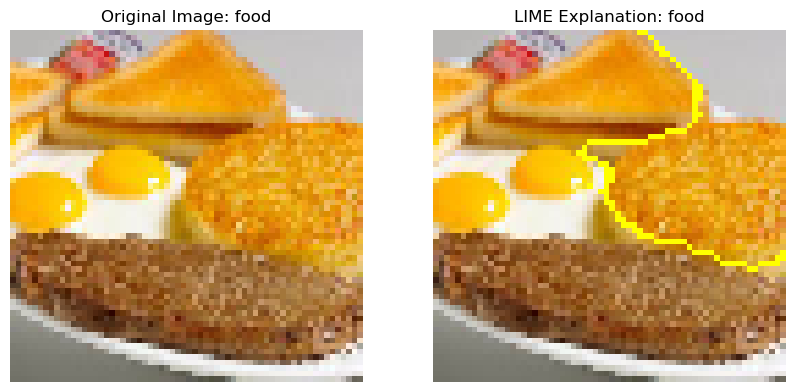

In [97]:
import numpy as np
import matplotlib.pyplot as plt
from lime import lime_image
from skimage.segmentation import mark_boundaries
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model(r"C:\Users\User\Downloads\cnn_final_model.h5")

# Define class names
class_names = ['drink', 'food', 'inside', 'menu', 'outside']

# Function to preprocess image for prediction
def preprocess_image(img_path, img_size=(64, 64)):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    img = load_img(img_path, target_size=img_size)
    img_arr = img_to_array(img) / 255.0
    return img_arr

# Load an image to explain
image_path = r"C:\Users\User\Desktop\CV\yelp_photos\balanced_labeled_photos\food\_5JAd6DvinTR9VxfK9pTaA.jpg"
image = preprocess_image(image_path)

# Create a batch of size 1 for prediction function
def predict_fn(images):
    images = np.array(images)
    return model.predict(images)

# Initialize LIME image explainer
explainer = lime_image.LimeImageExplainer()

# Explain prediction for the image
explanation = explainer.explain_instance(
    image,                      
    predict_fn,                 
    top_labels=5,
    hide_color=0,
    num_samples=1000            
)

# Get explanation for the top predicted class
top_predicted_class = explanation.top_labels[0]
temp, mask = explanation.get_image_and_mask(
    label=top_predicted_class,
    positive_only=True,
    num_features=5,
    hide_rest=False
)

# Plot original image and explanation
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.title(f"Original Image: {class_names[top_predicted_class]}")
plt.imshow(image)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title(f"LIME Explanation: {class_names[top_predicted_class]}")
plt.imshow(mark_boundaries(temp, mask))
plt.axis('off')

plt.show()

In [93]:
pip install shap

Note: you may need to restart the kernel to use updated packages.


C:\Users\User\anaconda3\Lib\site-packages\shap\explainers\_deep\deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
C:\Users\User\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(100, 64, 64, 3))']
  warnings.warn(msg)
C:\Users\User\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(200, 64, 64, 3))']
  warnings.warn(msg)


C:\Users\User\anaconda3\Lib\site-packages\keras\src\models\functional.py:238: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: input_layer_1
Received: inputs=['Tensor(shape=(1, 64, 64, 3))']
  warnings.warn(msg)


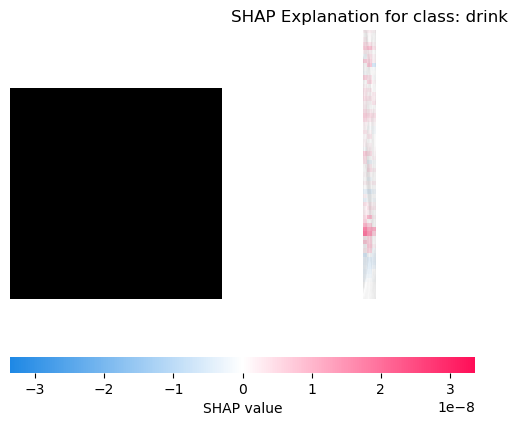

IndexError: index 1 is out of bounds for axis 0 with size 1

In [99]:
import shap
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

# Load your saved model
model = tf.keras.models.load_model(r"C:\Users\User\Downloads\cnn_final_model.h5")

# Define class names
class_names = ['drink', 'food', 'inside', 'menu', 'outside']

# Load and preprocess an image
def preprocess_image(img_path, img_size=(64, 64)):
    from tensorflow.keras.preprocessing.image import load_img, img_to_array
    img = load_img(img_path, target_size=img_size)
    img_arr = img_to_array(img) / 255.0
    return img_arr

image_path = r"C:\Users\User\Desktop\CV\yelp_photos\balanced_labeled_photos\food\_1I0z4OdTLB5zFZ7kZz-gg.jpg"  
image = preprocess_image(image_path)

# Add batch dimension
image_batch = np.expand_dims(image, axis=0)

background = X_train[np.random.choice(X_train.shape[0], 100, replace=False)]

explainer = shap.DeepExplainer(model, background)

# Calculate SHAP values for the image
shap_values = explainer.shap_values(image_batch)

# Plot SHAP explanations for each class
for i in range(len(class_names)):
    shap.image_plot([shap_values[i]], -image_batch, show=False)
    plt.title(f"SHAP Explanation for class: {class_names[i]}")
    plt.show()


In [ ]:
#i used chatgpt for solving errors